# Own Implied Volatility Calculation

Compute Black-Scholes implied volatility from cleaned SPY option mid prices, compare it with the yfinance IV column, and save the enriched options file.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm

## Settings

In [2]:
OPTIONS_PATH = Path("data/spy_options_clean.csv")
HISTORY_PATH = Path("data/SPY_history.csv")
OUTPUT_PATH = Path("data/spy_options_clean_with_iv.csv")
PLOT_PATH = Path("outputs/own_iv/iv_vs_strike.png")

# Same 13-week T-bill proxy printed in pull_data.ipynb when this market snapshot was pulled.
RISK_FREE_RATE = 0.0367

# Brent's method searches a wide but finite volatility interval.
MIN_SIGMA = 1e-4
MAX_SIGMA = 5.0

## Market Inputs

In [3]:
def load_spot_and_dividend_yield(path: Path) -> tuple[float, float]:
    history = pd.read_csv(path, parse_dates=["Date"])
    history = history.sort_values("Date")

    s0 = float(history["Close"].iloc[-1])
    dividends = history.loc[history["Dividends"] > 0, "Dividends"].tail(4)
    q = float(dividends.sum() / s0) if s0 > 0 else 0.0
    return s0, q


S0, DIVIDEND_YIELD = load_spot_and_dividend_yield(HISTORY_PATH)

print(f"S0: {S0:.4f}")
print(f"Dividend yield: {DIVIDEND_YIELD:.6f}")
print(f"Risk-free rate: {RISK_FREE_RATE:.4f}")

S0: 744.7800
Dividend yield: 0.010104
Risk-free rate: 0.0367


## Black-Scholes Helpers

In [4]:
def bs_price(sigma: float, S0: float, K: float, T: float, r: float, q: float, option_type: str = "call") -> float:
    # Price a European call or put under Black-Scholes with continuous dividends.
    if sigma <= 0 or S0 <= 0 or K <= 0 or T <= 0:
        return np.nan

    vol_sqrt_t = sigma * np.sqrt(T)
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    if option_type == "call":
        return S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    if option_type == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * np.exp(-q * T) * norm.cdf(-d1)
    raise ValueError(f"Unknown option_type: {option_type}")


def implied_vol(market_price: float, S0: float, K: float, T: float, r: float, q: float, option_type: str = "call") -> float:
    # Return NaN when the quote has no valid BS implied-vol root in the search interval.
    if not np.isfinite([market_price, S0, K, T, r, q]).all() or market_price <= 0:
        return np.nan

    objective = lambda sigma: bs_price(sigma, S0, K, T, r, q, option_type) - market_price
    try:
        return brentq(objective, MIN_SIGMA, MAX_SIGMA)
    except ValueError:
        return np.nan

## Calculate Own IV

In [5]:
options = pd.read_csv(OPTIONS_PATH)

expiry = pd.to_datetime(options["expiry"], errors="coerce")
pull_date = pd.to_datetime(options["pull_date"], errors="coerce")

options["S0"] = S0
options["q"] = DIVIDEND_YIELD
options["r"] = RISK_FREE_RATE
options["T"] = (expiry - pull_date).dt.days / 365.0

options["iv_own"] = options.apply(
    lambda row: implied_vol(
        market_price=float(row["mid"]),
        S0=float(row["S0"]),
        K=float(row["strike"]),
        T=float(row["T"]),
        r=float(row["r"]),
        q=float(row["q"]),
        option_type=str(row["type"]).lower(),
    ),
    axis=1,
)

options["iv_diff"] = options["iv_own"] - options["impliedVolatility"]
options.to_csv(OUTPUT_PATH, index=False)

summary = {
    "rows": len(options),
    "valid_iv_own": int(options["iv_own"].notna().sum()),
    "missing_iv_own": int(options["iv_own"].isna().sum()),
    "mean_abs_diff": float(options["iv_diff"].abs().mean()),
    "output": str(OUTPUT_PATH),
}

summary

{'rows': 973,
 'valid_iv_own': 899,
 'missing_iv_own': 74,
 'mean_abs_diff': 0.03306781406594499,
 'output': 'data/spy_options_clean_with_iv.csv'}

## Inspect Failed Roots

In [6]:
# Failed rows usually reflect stale quotes, arbitrage violations, or impossible mid prices.
failed_roots = options.loc[
    options["iv_own"].isna(),
    ["contractSymbol", "type", "expiry", "strike", "bid", "ask", "mid", "T", "impliedVolatility"],
]

failed_roots.head(20)

,contractSymbol,type,expiry,strike,bid,ask,mid,T,impliedVolatility
0,SPY260706C00625000,call,2026-07-06,625.0,117.82,121.34,119.580,0.005479,1.182133
1,SPY260706C00660000,call,2026-07-06,660.0,82.83,86.35,84.590,0.005479,0.878175
2,SPY260706C00670000,call,2026-07-06,670.0,72.83,76.35,74.590,0.005479,0.791018
3,SPY260706C00700000,call,2026-07-06,700.0,42.84,46.36,44.600,0.005479,0.527104
4,SPY260706C00703000,call,2026-07-06,703.0,39.84,43.36,41.600,0.005479,0.500005
5,SPY260706C00705000,call,2026-07-06,705.0,37.85,41.36,39.605,0.005479,0.481939
6,SPY260706C00706000,call,2026-07-06,706.0,36.89,40.36,38.625,0.005479,0.472662
7,SPY260706C00709000,call,2026-07-06,709.0,33.85,37.36,35.605,0.005479,0.445196
8,SPY260706C00710000,call,2026-07-06,710.0,32.85,36.36,34.605,0.005479,0.435919
9,SPY260706C00711000,call,2026-07-06,711.0,31.85,35.37,33.610,0.005479,0.427496


## IV vs Strike

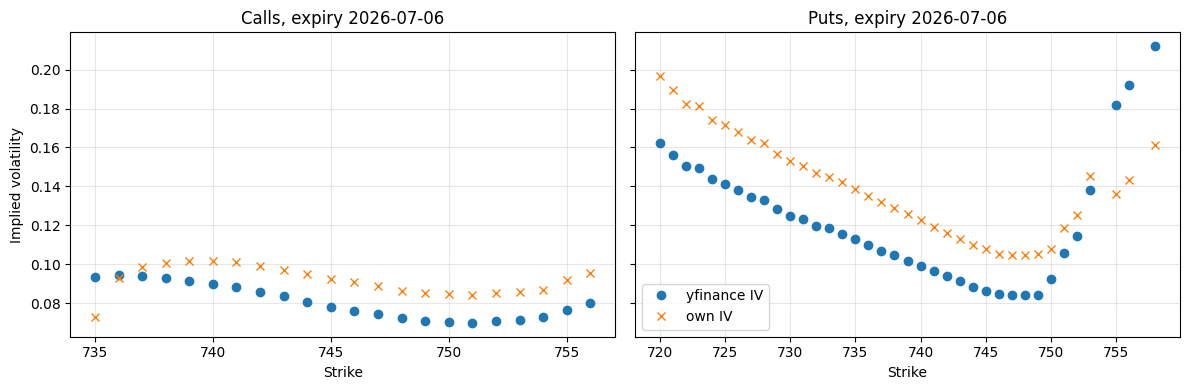

Saved plot to outputs/own_iv/iv_vs_strike.png


In [7]:
plot_data = options.dropna(subset=["iv_own", "impliedVolatility", "strike", "expiry", "type"]).copy()
plot_expiry = plot_data["expiry"].sort_values().iloc[0]
plot_data = plot_data.loc[plot_data["expiry"] == plot_expiry]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, option_type in zip(axes, ["call", "put"]):
    subset = plot_data.loc[plot_data["type"] == option_type].sort_values("strike")
    ax.plot(subset["strike"], subset["impliedVolatility"], marker="o", linestyle="", label="yfinance IV")
    ax.plot(subset["strike"], subset["iv_own"], marker="x", linestyle="", label="own IV")
    ax.set_title(f"{option_type.title()}s, expiry {plot_expiry}")
    ax.set_xlabel("Strike")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Implied volatility")
axes[1].legend(loc="best")
fig.tight_layout()

PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_PATH, dpi=150)
plt.show()

print(f"Saved plot to {PLOT_PATH}")